# CLIP-Style Contrastive Learning — Training

In [1]:
!pip install torch torchvision transformers kagglehub

## Download Dataset
Downloads Flickr8k from Kaggle via `kagglehub`. Requires a one-time Kaggle setup:
1. Go to kaggle.com → Settings → API → Create New Token
2. Upload the downloaded `kaggle.json` to `~/.kaggle/kaggle.json` on JupyterHub

In [2]:
import os
import shutil
import kagglehub

DATASET_DIR = "dataset"
IMAGES_DIR = os.path.join(DATASET_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATASET_DIR, "captions.txt")

if os.path.isdir(IMAGES_DIR) and os.path.isfile(CAPTIONS_FILE):
    print("Dataset already exists, skipping download.")
else:
    print("Downloading Flickr8k from Kaggle...")
    path = kagglehub.dataset_download("adityajn105/flickr8k")
    print(f"Downloaded to: {path}")

    os.makedirs(DATASET_DIR, exist_ok=True)

    src_images = os.path.join(path, "Images")
    src_captions = os.path.join(path, "captions.txt")

    if not os.path.isdir(IMAGES_DIR):
        shutil.copytree(src_images, IMAGES_DIR)
    if not os.path.isfile(CAPTIONS_FILE):
        shutil.copy2(src_captions, CAPTIONS_FILE)

    print(f"Dataset ready: {len(os.listdir(IMAGES_DIR))} images, captions.txt present.")

Dataset already exists, skipping download.


In [3]:
import csv
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from transformers import BertModel, BertTokenizer

In [4]:
# --------------- Config ---------------
CAPTIONS_FILE = "dataset/captions.txt"
IMAGES_DIR = "dataset/Images"
CHECKPOINT_DIR = "checkpoints"
EPOCHS = 10
LR = 1e-4
LOG_EVERY = 50
VAL_SPLIT = 0.1
BATCH_SIZE = 64
MAX_TOKEN_LENGTH = 64
EMBED_DIM = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

Device: cuda


## Data Pipeline

In [6]:
class Flickr8kDataset(Dataset):
    def __init__(self, captions_file: str, images_dir: str):
        self.images_dir = images_dir

        self.image_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

        self.samples = []  # list of (image_filename, caption)
        with open(captions_file, "r") as f:
            reader = csv.reader(f)
            next(reader)  # skip header
            for row in reader:
                image_filename = row[0]
                caption = row[1]
                self.samples.append((image_filename, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_filename, caption = self.samples[idx]
        image_path = os.path.join(self.images_dir, image_filename)

        image = Image.open(image_path).convert("RGB")
        image = self.image_transform(image)

        tokens = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=MAX_TOKEN_LENGTH,
            return_tensors="pt",
        )
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        return image, input_ids, attention_mask

In [7]:
dataset = Flickr8kDataset(CAPTIONS_FILE, IMAGES_DIR)
val_size = int(len(dataset) * VAL_SPLIT)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)
print(f"Train: {train_size}  Val: {val_size}")

num_workers = 4 if torch.cuda.is_available() else 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

Train: 36410  Val: 4045


## Image Encoder

In [8]:
class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        # Remove final classification layer — keep everything up to avgpool
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # output: (batch, 512, 1, 1)

        self.projection = nn.Sequential(
            nn.Linear(512, EMBED_DIM),
            nn.ReLU(),
            nn.Linear(EMBED_DIM, EMBED_DIM),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images).squeeze(-1).squeeze(-1)  # (batch, 512)
        projected = self.projection(features)                      # (batch, 256)
        return F.normalize(projected, dim=-1)                      # L2-normalized

## Text Encoder

In [9]:
class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.projection = nn.Sequential(
            nn.Linear(768, EMBED_DIM),
            nn.ReLU(),
            nn.Linear(EMBED_DIM, EMBED_DIM),
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [CLS] token — (batch, 768)
        projected = self.projection(cls_embedding)            # (batch, 256)
        return F.normalize(projected, dim=-1)                 # L2-normalized

## InfoNCE Loss

In [10]:
class CLIPLoss(nn.Module):
    def __init__(self, initial_temperature: float = 0.07):
        super().__init__()
        # Learnable log-temperature: optimized during training alongside the encoders.
        # We store log(temperature) so that exp() always yields a positive scale factor.
        self.log_temperature = nn.Parameter(torch.tensor(initial_temperature).log())

    def forward(self, image_embeddings: torch.Tensor, text_embeddings: torch.Tensor) -> torch.Tensor:
        # Both inputs are L2-normalized, so matmul == cosine similarity
        # logits shape: (N, N)
        temperature = self.log_temperature.exp()
        logits = (image_embeddings @ text_embeddings.T) / temperature

        # Targets: the diagonal — pair i matches pair i
        N = logits.size(0)
        targets = torch.arange(N, device=logits.device)

        # Symmetric cross-entropy: image→text + text→image
        loss_i2t = F.cross_entropy(logits, targets)       # rows
        loss_t2i = F.cross_entropy(logits.T, targets)     # columns
        return (loss_i2t + loss_t2i) / 2

## Models & Optimizer

In [11]:
image_encoder = ImageEncoder().to(device)
text_encoder = TextEncoder().to(device)
loss_fn = CLIPLoss().to(device)

optimizer = Adam(
    list(image_encoder.parameters()) + list(text_encoder.parameters()) + list(loss_fn.parameters()),
    lr=LR,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Training Functions

In [12]:
def train_one_epoch(image_encoder, text_encoder, loss_fn, optimizer, dataloader, device, epoch):
    image_encoder.train()
    text_encoder.train()

    running_loss = 0.0
    for step, (images, input_ids, attention_mask) in enumerate(dataloader):
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        image_emb = image_encoder(images)
        text_emb = text_encoder(input_ids, attention_mask)
        loss = loss_fn(image_emb, text_emb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (step + 1) % LOG_EVERY == 0:
            avg = running_loss / LOG_EVERY
            temp = loss_fn.log_temperature.exp().item()
            print(f"  Epoch {epoch+1} | Step {step+1:>4d} | Loss {avg:.4f} | Temp {temp:.4f}")
            running_loss = 0.0

    return running_loss


@torch.no_grad()
def validate(image_encoder, text_encoder, loss_fn, dataloader, device):
    image_encoder.eval()
    text_encoder.eval()

    total_loss = 0.0
    num_batches = 0
    for images, input_ids, attention_mask in dataloader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        image_emb = image_encoder(images)
        text_emb = text_encoder(input_ids, attention_mask)
        loss = loss_fn(image_emb, text_emb)

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

## Training Loop

In [13]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    t0 = time.time()
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*50}")

    train_one_epoch(image_encoder, text_encoder, loss_fn, optimizer, train_loader, device, epoch)

    val_loss = validate(image_encoder, text_encoder, loss_fn, val_loader, device)
    elapsed = time.time() - t0
    print(f"  Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "image_encoder": image_encoder.state_dict(),
            "text_encoder": text_encoder.state_dict(),
            "loss_fn": loss_fn.state_dict(),
            "optimizer": optimizer.state_dict(),
        }
        path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
        torch.save(checkpoint, path)
        print(f"  ** New best model saved (val_loss={val_loss:.4f}) **")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch 1/10
  Epoch 1 | Step   50 | Loss 3.1505 | Temp 0.0698
  Epoch 1 | Step  100 | Loss 2.1530 | Temp 0.0694
  Epoch 1 | Step  150 | Loss 1.6785 | Temp 0.0691
  Epoch 1 | Step  200 | Loss 1.5687 | Temp 0.0688
  Epoch 1 | Step  250 | Loss 1.3749 | Temp 0.0684
  Epoch 1 | Step  300 | Loss 1.2434 | Temp 0.0681
  Epoch 1 | Step  350 | Loss 1.1262 | Temp 0.0678
  Epoch 1 | Step  400 | Loss 1.0389 | Temp 0.0675
  Epoch 1 | Step  450 | Loss 0.9839 | Temp 0.0671
  Epoch 1 | Step  500 | Loss 0.9393 | Temp 0.0668
  Epoch 1 | Step  550 | Loss 0.8447 | Temp 0.0665
  Val Loss: 0.7464 | Time: 54.2s
  ** New best model saved (val_loss=0.7464) **

Epoch 2/10
  Epoch 2 | Step   50 | Loss 0.5477 | Temp 0.0660
  Epoch 2 | Step  100 | Loss 0.5263 | Temp 0.0657
  Epoch 2 | Step  150 | Loss 0.5119 | Temp 0.0653
  Epoch 2 | Step  200 | Loss 0.4951 | Temp 0.0650
  Epoch 2 | Step  250 | Loss 0.5187 | Temp 0.0647
  Epoch 2 | Step  300 | Loss 0.5123 | Temp 0.0644
  Epoch 2 | Step  350 | Loss 0.4708 | Temp 0.0

## Step 6 — Visualization

Two presentation-ready plots:
1. **Similarity matrix heatmap** — 10 image-text pairs, trained vs. untrained (diagonal = alignment)
2. **UMAP projection** — 200 pairs in the shared 256-d space, reduced to 2D

In [14]:
!pip install umap-learn matplotlib

Loaded best checkpoint (epoch 10, val_loss=0.4171)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


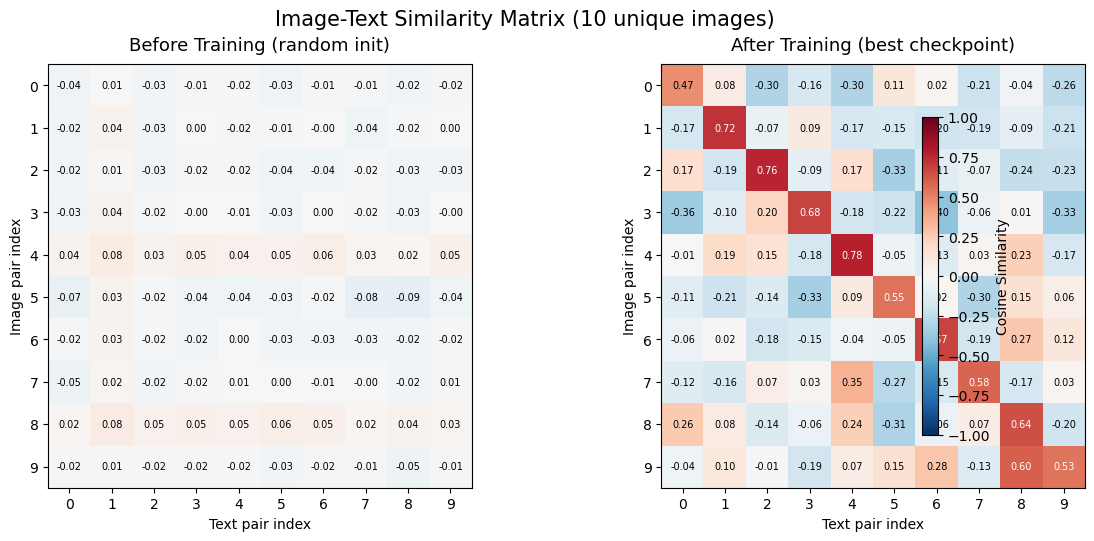

Saved → similarity_matrix.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ── Helper: embed specific dataset indices ──────────────────────
@torch.no_grad()
def embed_indices(img_enc, txt_enc, dataset, indices, dev):
    """Embed specific samples by index. Returns (image_embs, text_embs)."""
    images, ids, masks = [], [], []
    for idx in indices:
        img, input_id, attn_mask = dataset[idx]
        images.append(img)
        ids.append(input_id)
        masks.append(attn_mask)
    images = torch.stack(images).to(dev)
    ids = torch.stack(ids).to(dev)
    masks = torch.stack(masks).to(dev)
    return img_enc(images), txt_enc(ids, masks)

# ── Pick 10 unique images from the validation set ──────────────
# Flickr8k has 5 captions per image — we need 10 distinct images
seen_images = set()
unique_indices = []
for i in range(len(val_dataset)):
    real_idx = val_dataset.indices[i]
    img_filename = val_dataset.dataset.samples[real_idx][0]
    if img_filename not in seen_images:
        seen_images.add(img_filename)
        unique_indices.append(real_idx)
    if len(unique_indices) == 10:
        break

N_SIM = len(unique_indices)

# ── Load best checkpoint for the trained model ──────────────────
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "best_model.pt"), map_location=device, weights_only=True)
image_encoder.load_state_dict(ckpt["image_encoder"])
text_encoder.load_state_dict(ckpt["text_encoder"])
image_encoder.eval()
text_encoder.eval()
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")

# Trained model embeddings
img_e_trained, txt_e_trained = embed_indices(image_encoder, text_encoder, dataset, unique_indices, device)
sim_trained = (img_e_trained @ txt_e_trained.T).cpu().numpy()

# Untrained (random init) model embeddings
img_enc_rand = ImageEncoder().to(device).eval()
txt_enc_rand = TextEncoder().to(device).eval()
img_e_rand, txt_e_rand = embed_indices(img_enc_rand, txt_enc_rand, dataset, unique_indices, device)
sim_rand = (img_e_rand @ txt_e_rand.T).cpu().numpy()

# ── Plot side-by-side ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, mat, title in [
    (ax1, sim_rand,    "Before Training (random init)"),
    (ax2, sim_trained, "After Training (best checkpoint)"),
]:
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Text pair index")
    ax.set_ylabel("Image pair index")
    ax.set_xticks(range(N_SIM))
    ax.set_yticks(range(N_SIM))
    for i in range(N_SIM):
        for j in range(N_SIM):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i, j]) > 0.5 else "black")

fig.suptitle("Image-Text Similarity Matrix (10 unique images)", fontsize=15)
cbar = fig.colorbar(im, ax=[ax1, ax2], shrink=0.75, label="Cosine Similarity", pad=0.02)
fig.subplots_adjust(top=0.88, wspace=0.3)
plt.savefig("similarity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → similarity_matrix.png")

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


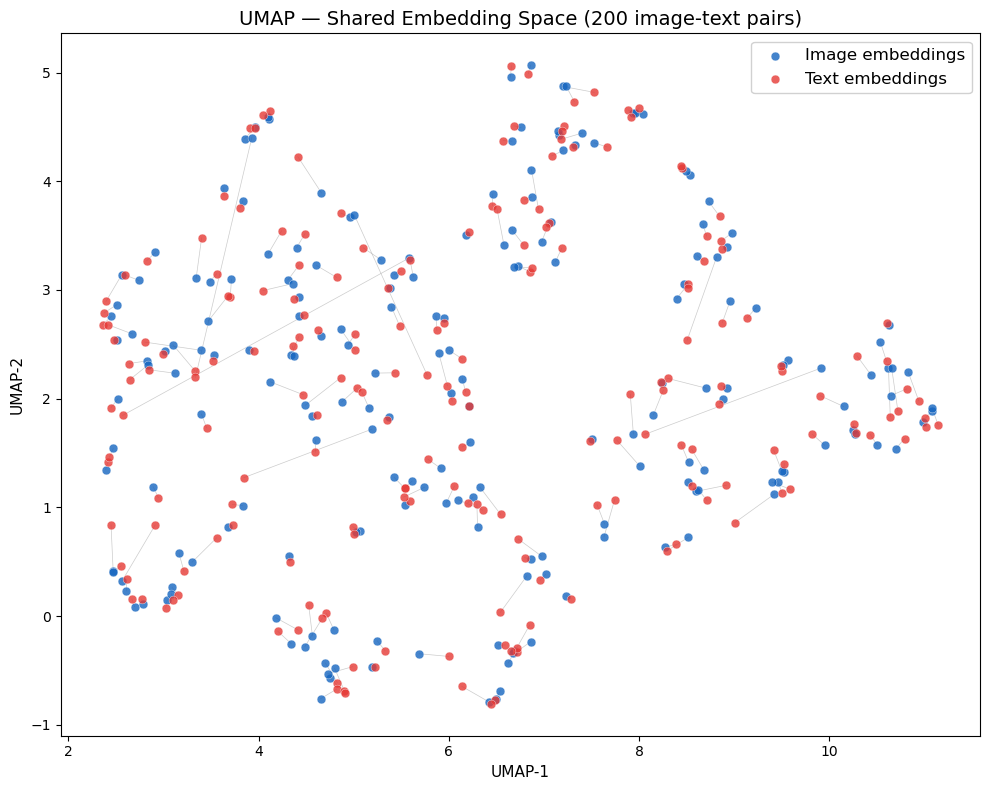

Saved → umap_embeddings.png


In [16]:
import umap

# ── 2. UMAP Projection (200 unique image-text pairs) ───────────
N_UMAP = 200

# Pick 200 unique images from the full dataset
seen_umap = set()
umap_indices = []
for i in range(len(dataset)):
    img_filename = dataset.samples[i][0]
    if img_filename not in seen_umap:
        seen_umap.add(img_filename)
        umap_indices.append(i)
    if len(umap_indices) == N_UMAP:
        break

img_embs, txt_embs = embed_indices(image_encoder, text_encoder, dataset, umap_indices, device)
img_np = img_embs.cpu().numpy()
txt_np = txt_embs.cpu().numpy()

# Stack: first N are images, next N are texts
all_embs = np.concatenate([img_np, txt_np], axis=0)  # (400, 256)

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(all_embs)

img_coords = coords[:N_UMAP]
txt_coords = coords[N_UMAP:]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Draw connecting lines first (behind the dots)
for i in range(N_UMAP):
    ax.plot(
        [img_coords[i, 0], txt_coords[i, 0]],
        [img_coords[i, 1], txt_coords[i, 1]],
        color="#999999", linewidth=0.5, alpha=0.5,
    )

ax.scatter(img_coords[:, 0], img_coords[:, 1],
           c="#1565C0", s=40, alpha=0.8, label="Image embeddings", edgecolors="white", linewidths=0.3, zorder=3)
ax.scatter(txt_coords[:, 0], txt_coords[:, 1],
           c="#E53935", s=40, alpha=0.8, label="Text embeddings", edgecolors="white", linewidths=0.3, zorder=3)

ax.set_title("UMAP — Shared Embedding Space (200 image-text pairs)", fontsize=14)
ax.legend(fontsize=12, loc="best", framealpha=0.9)
ax.set_xlabel("UMAP-1", fontsize=11)
ax.set_ylabel("UMAP-2", fontsize=11)
plt.tight_layout()
plt.savefig("umap_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → umap_embeddings.png")